In [2]:
from dataset import load_dataset
import pandas as pd
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik,plot_ranked_pdfs,plot_pdf_with_true_target
from regression.RandomForest.random_forest_regression import RandomForestRegressorModel
import joblib
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [3]:
TARGET_COL = "trq_margin"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/random_forest_regressor/model_margin/"
MODEL_PATH="random_forest_model_margin.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [4]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)


X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values

In [5]:
rf_model = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=5
)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [ ]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)

In [1]:
id=24
test_row=test_df.iloc[id]
trq_margin_true=test_row["trq_margin"]
testX = test_df.loc[[id], FEUTURE].to_numpy()
tree_preds = rf_model.predict_trees(testX)
tree_preds.head()
mean=np.median(tree_preds)

NameError: name 'test_df' is not defined

In [ ]:
ranking,best =  fit_rank_pdfs_loglik(tree_preds)

In [ ]:
plot_ranked_pdfs(ranking,tree_preds)

In [ ]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],trq_margin_true,mean)

In [ ]:
from regression.probabilistic_rf_scoring import get_regression_score
from tqdm import tqdm


rng = np.random.default_rng(42)

rows_out = []

pbar = tqdm(range(len(test_df)), desc="Processing test set", unit="row")

for i in pbar:

    test_row = test_df.iloc[i]

    trq_measured = float(test_row["trq_measured"])
    trq_target_true = float(test_row["trq_target"])
    test_x = test_row[FEUTURE].to_frame().T


    test_y_true = (trq_measured / trq_target_true - 1.0) * 100.0


    pbar.set_postfix_str("predicting")
    target_pred = rf_model.predict_trees(x0)[0].astype(float)


    pbar.set_postfix_str("fitting pdf")
    ranking, best = fit_rank_pdfs_loglik(tree_preds)

    if best is None or best.get("pdf_args") is None:
        continue

    best_pdf = best["pdf_type"]
    best_args = best["pdf_args"]


    pbar.set_postfix_str("scoring")
    score_true = float(get_regression_score(best_pdf, best_args, float(test_y_true)))
    score_pred = float(get_regression_score(best_pdf, best_args, float(np.mean(target_pred))))

    out = test_row[FEUTURE].to_dict()
    out.update({
        "idx": i,
        "trq_target_true": trq_target_true,
        "trq_target_pred": target_pred,
        "y_true": float(test_y_true),
        "y_pred": float(np.mean(target_pred)),
        "best_pdf": best_pdf,
        "best_pdf_args": best_args,
        "best_loglik": float(best.get("loglik", np.nan)),
        "score_true": score_true,
        "score_pred": score_pred,
    })

    rows_out.append(out)

pbar.close()

df_report = pd.DataFrame(rows_out)
df_report.head()


In [15]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    rf_model.model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(r.importances_mean, index=FEUTURE)\
             .sort_values(ascending=False)

print(perm_imp.head(10))

/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


trq_measured    1.000391
oat             0.398868
mgt             0.335482
pa              0.104615
np_ng_ratio     0.085805
ias             0.016432
dtype: float64


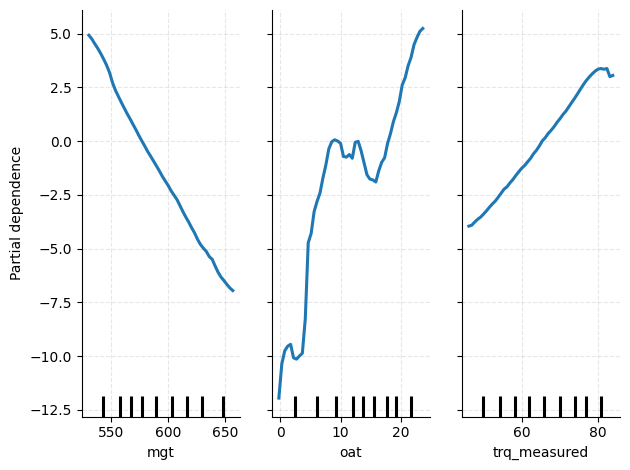

In [16]:
from sklearn.inspection import PartialDependenceDisplay

X_test_df = pd.DataFrame(X_test, columns=FEUTURE)
top_main = ["mgt", "oat", "trq_measured"]

PartialDependenceDisplay.from_estimator(
    rf_model.model if hasattr(rf_model, "model") else rf_model,
    X_test_df,
    features=top_main,
    grid_resolution=50
)

plt.tight_layout()
plt.show()